# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MA-1305/Project_Mahin-1305/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Abstract

This project develops a decision-support approach for prioritizing pages that may benefit from content review. Using an anonymized FlyRank content-refresh dataset containing 30,000 rows and 44 columns, the analysis combines observable search and content signals with a transparent baseline and machine-learning models.

The task is framed as a classification and ranking problem using a proxy declining label derived from observed trend direction. Model performance is evaluated using ranking-oriented metrics, with Precision@50 used to reflect the practical need to prioritize a limited review queue.

The results indicate that the learned Random Forest model provides stronger ranking performance than the transparent baseline on the starter dataset. However, the analysis is observational and uses a proxy target, so the results should be treated as directional decision-support rather than evidence that a content refresh will cause improved search performance.

The final recommendation is to use model scores to prioritize human review while retaining editorial judgment and additional validation before making content changes.

## 1. Question

*The research question and the decision it supports.*

Research Question:

Which pages should be reviewed first for content refresh based on observable search and content signals?

Decision Supported:

The analysis supports content teams in deciding which pages should receive attention first when review capacity is limited.

The goal is to rank pages by their likelihood of being useful refresh candidates rather than to guarantee that updating a page will improve its performance.

A wrong recommendation could waste editing time on a page that does not need changes, while a missed high-priority page could delay an opportunity to improve or protect search performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data Source:

This project uses the FlyRank ML Internship dataset. The starter analysis uses the anonymized content-refresh dataset containing 30,000 rows and 44 columns.

The main input is:

data/raw/content_refresh_anonymized.csv

The dataset contains observable search and content signals such as impressions, clicks, CTR, average position, sessions, engagement rate, scroll rate, content age, word count, and other content metadata.

The starter label is based on:

is_declining_label = trend_direction == "down"

For feature preparation, pages with insufficient evidence are filtered using the starter pipeline rules, including impressions_90d > 0 and content_age_days >= 90. Duplicate content IDs are removed.

The analysis excludes client names, raw URLs, raw search queries, domains, titles, and other private information.

The data is treated as anonymized and public-safe decision-support data.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Methodology:

The task is treated as a classification and ranking problem.

The target is whether a page is classified as declining using the starter proxy label:

is_declining_label = trend_direction == "down"

The model uses observable features such as search volume, competition, CPC, word count, character count, impressions, clicks, sessions, content age, freshness, CTR, average position, engagement rate, scroll rate, and AI-traffic percentage, together with relevant categorical content and search fields.

A transparent baseline is used before the machine-learning model. The baseline combines visibility, freshness risk, position opportunity, and content-depth signals.

The machine-learning comparison includes logistic regression, decision tree, and random forest. Random Forest is used as the strongest learned model in the starter results.

The main evaluation metric is Precision@50 because the practical decision is to identify a limited number of pages for review.

Client-holdout validation is used so that complete clients are kept out of training and evaluated separately.

Leakage checks are used to ensure that target information or future information is not used as a model feature. Product decision flags are also excluded because using them would cause the model to reproduce an existing decision instead of discovering useful signal.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

           Method  Precision@50
0  Baseline Rules          0.24
1   Random Forest          0.74


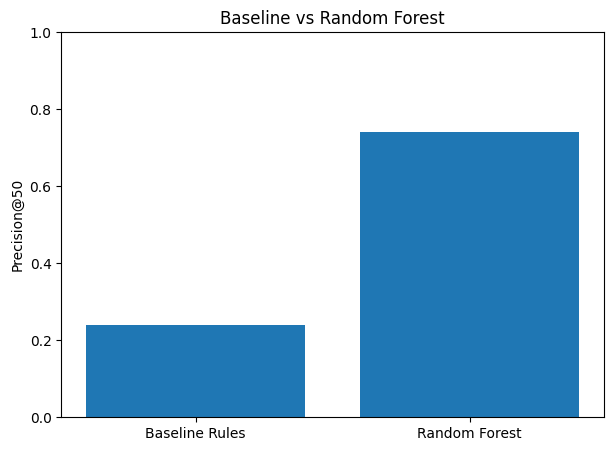

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Method": ["Baseline Rules", "Random Forest"],
    "Precision@50": [0.240, 0.740]
})

print(results)

plt.figure(figsize=(7, 5))
plt.bar(results["Method"], results["Precision@50"])
plt.ylabel("Precision@50")
plt.title("Baseline vs Random Forest")
plt.ylim(0, 1)
plt.show()

Results:

The learned models performed better than the transparent baseline on the starter dataset.

The baseline rules achieved:

ROC AUC: 0.627
Average Precision: 0.468
Precision@50: 0.240

The Random Forest model achieved:

ROC AUC: 0.750
Average Precision: 0.618
Precision@50: 0.740

The Precision@50 result means that the baseline correctly identified approximately 12 of its top 50 recommended pages, while the Random Forest identified approximately 37 of its top 50 pages according to the selected label.

Therefore, on this anonymized starter slice, the Random Forest produced a substantially stronger ranking than the fixed baseline.

These results should be interpreted as measured performance on the available dataset and not as proof that refreshing a page will cause its traffic or search performance to improve.

## 5. Limitations

*What this work cannot claim.*

Limitations:

This analysis has several limitations.

First, the starter dataset contains 30,000 anonymized rows and is only a slice of the much larger FlyRank warehouse. Therefore, the results should not be treated as a benchmark for the entire approximately 79 million-row warehouse.

Second, the starter target is a proxy based on trend_direction rather than a future outcome. A stronger study would define features using a historical window and predict an outcome in a separate future window.

Third, the analysis is observational. It can identify patterns and support prioritization, but it cannot prove that refreshing a page will cause traffic, clicks, rankings, or engagement to improve.

Fourth, search performance can be affected by seasonality, consolidation between related pages, changes in search results, and random variation. These factors may cause a page to appear to be declining even when a refresh is not necessarily the correct action.

Finally, model predictions should be reviewed by a human before any content changes are made.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Ranked Recommendations:

1. Review high-confidence pages first.
   Prioritize pages that receive strong model scores and have enough search exposure to make the recommendation meaningful.

2. Review declining pages with meaningful demand.
   Pages showing declining trends while still receiving substantial impressions should receive higher review priority because they have measurable search exposure.

3. Review stale pages with continued visibility.
   Older pages that still receive meaningful impressions may represent opportunities for content refresh or improvement.

4. Review strong-position pages with relatively low CTR.
   Pages that appear in strong search positions but receive relatively low CTR can be candidates for title, snippet, or intent-match review.

5. Keep human review in the workflow.
   Model scores should prioritize the review queue but should not automatically trigger publishing, deletion, or major content decisions.

The ranked recommendations are intended to help content teams spend limited review time on the most promising candidates first.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [11]:
import pandas as pd

results = pd.DataFrame({
    "Method": [
        "Baseline Rules",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "ROC AUC": [
        0.627,
        0.700,
        0.742,
        0.750
    ],
    "Average Precision": [
        0.468,
        0.522,
        0.575,
        0.618
    ],
    "Precision@50": [
        0.240,
        0.400,
        0.540,
        0.740
    ]
})

results

,Method,ROC AUC,Average Precision,Precision@50
0,Baseline Rules,0.627,0.468,0.24
1,Logistic Regression,0.700,0.522,0.40
2,Decision Tree,0.742,0.575,0.54
3,Random Forest,0.750,0.618,0.74


Artifacts:

The final research paper will include the following artifacts:

1. Baseline vs Random Forest Precision@50 comparison chart.

2. Model performance comparison table containing:
   - ROC AUC
   - Average Precision
   - Precision@50

3. Ranked recommendation/action table showing:
   - Priority
   - Recommended action
   - Reason
   - Confidence

4. A short explanation of the main model result and its limitations.

These artifacts provide a compact visual summary of the analysis and make the comparison between the baseline and learned model easier to understand.

## Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship track.

The analysis uses the anonymized FlyRank content-refresh starter dataset provided for the internship.

FlyRank: https://flyrank.ai

The dataset and analysis are used for educational and decision-support purposes. No private client names, raw URLs, raw search queries, or other sensitive information are included in this public-facing work.

## 5-Minute Demo Outline

### 0:00–0:45 — Problem
Explain that content teams have limited time and need a way to prioritize pages for review.

### 0:45–1:30 — Data
Introduce the anonymized 30,000-row content-refresh dataset and the observable search/content signals.

### 1:30–2:30 — Method
Explain the transparent baseline, the machine-learning model, the proxy declining label, and client-holdout validation.

### 2:30–3:30 — Results
Show the baseline versus Random Forest performance using ROC AUC, Average Precision, and Precision@50.

### 3:30–4:30 — Action Playbook
Show how model scores are converted into a ranked review queue with reason codes.

### 4:30–5:00 — Limitations
Explain that the analysis is observational, uses a proxy target, and requires human review before content changes.

## Social-Post Cut

I built a machine-learning decision-support workflow for prioritizing content-refresh opportunities using an anonymized search/content dataset.

The project compares a transparent baseline with Random Forest and uses Precision@50 to focus on the practical problem of ranking a limited review queue.

The key lesson: a stronger model can improve prioritization, but model predictions should support human decisions rather than replace them.

## Employer-Facing Summary

I built and evaluated a practical machine-learning workflow for ranking pages that may need content review.

The project demonstrates skills in Python, data preparation, feature engineering, leakage checking, model comparison, client-holdout validation, ranking metrics, and translating model output into an actionable review queue.

The results are presented as decision-support evidence, with clear limitations and human-review safeguards rather than unsupported causal claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
